# Data distribution analysis

In [1]:
import warnings
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
from PIL import Image

import torch
from torchvision import models

import albumentations as A
from albumentations.pytorch import ToTensorV2

/home/zhenyi/anaconda3/envs/fundusegmenter/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# data folder path
path_vampire_train = './datasets/Vampire/training/images'
path_vampire_test = './datasets/Vampire/testing/images'
path_idrid_train = './datasets/IDRID/training/images'
path_idrid_test = './datasets/IDRID/testing/images'
path_drishti_gs_train = './datasets/Drishti-GS/training/images'
path_drishti_gs_test = './datasets/Drishti-GS/testing/images'
path_rim_one_r3_train = './datasets/RIM-ONE-r3/training/images'
path_rim_one_r3_test = './datasets/RIM-ONE-r3/testing/images'
path_refuge_train = './datasets/REFUGE/training/images'
path_refuge_val = './datasets/REFUGE/validation/images'
path_refuge_test = './datasets/REFUGE/testing/images'

# path for saving results
domain_data_save = './Domain datasets distribution analysis.svg'
all_data_save = './All datasets distribution analysis.svg'

In [3]:
warnings.filterwarnings("ignore", category=FutureWarning)

#load pre-trained VGG16
model = models.vgg16(pretrained=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = A.Compose(
    [A.Resize(height=224, width=224, interpolation=cv2.INTER_CUBIC, p=1.0), 
     A.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD, max_pixel_value=1),
     ToTensorV2(),
    ])

# get images from path
def get_image(image_path):
    image_list = os.listdir(image_path)
    image_all = []
    for img in image_list:
        image = np.asarray(Image.open(image_path+os.sep+img))
        transformed = transform(image=image)
        transformed_image = transformed['image']
        image_all.append(transformed_image)
    num_image = len(image_list)
    return image_all, num_image

# get features through VGG16
def get_feature(model, device, image):
    model = model
    device = device
    image = image
    model.to(device)

    features_all = []
    model.eval()
    with torch.no_grad():
        for img in image: 
            img = img.unsqueeze(0)
            img = img.to(device)
            features = model(img)
            features_all.append(features.to('cpu'))
    features = torch.cat(features_all, 0)
    return features

# T-SNE setting
tsne = TSNE(n_components=2, perplexity=20, learning_rate='auto', max_iter=100000, n_iter_without_progress=500, 
            init='pca', random_state=112316)

# get all the required data
image_vampire_train, num_vampire_train = get_image(path_vampire_train)
image_vampire_test, num_vampire_test = get_image(path_vampire_test)
image_idrid_train, num_idrid_train = get_image(path_idrid_train)
image_idrid_test, num_idrid_test = get_image(path_idrid_test)
image_drishti_gs_train, num_drishti_gs_train = get_image(path_drishti_gs_train)
image_drishti_gs_test, num_drishti_gs_test = get_image(path_drishti_gs_test)
image_rim_one_r3_train, num_rim_one_r3_train = get_image(path_rim_one_r3_train)
image_rim_one_r3_test, num_rim_one_r3_test = get_image(path_rim_one_r3_test)
image_refuge_train, num_refuge_train = get_image(path_refuge_train)
image_refuge_val, num_refuge_val = get_image(path_refuge_val)
image_refuge_test, num_refuge_test = get_image(path_refuge_test)

/home/zhenyi/anaconda3/envs/fundusegmenter/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zhenyi/anaconda3/envs/fundusegmenter/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


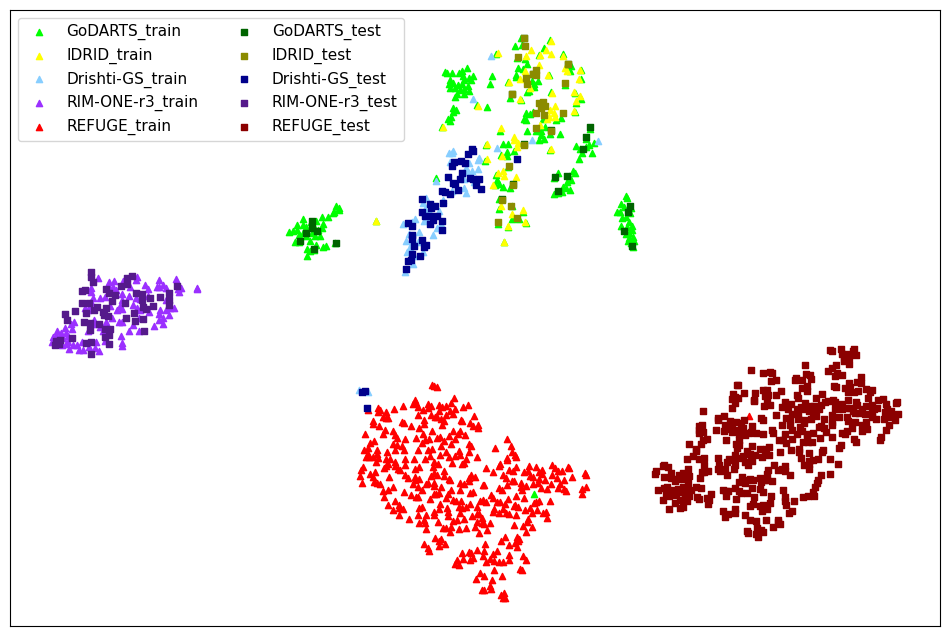

In [4]:
# T-SNE calculation of all datasets
image_all = image_vampire_train + image_vampire_test + image_idrid_train + image_idrid_test +\
            image_drishti_gs_train + image_drishti_gs_test + image_rim_one_r3_train +\
            image_rim_one_r3_test + image_refuge_train + image_refuge_test
feature_all = get_feature(model, device, image_all)
tsne_all = tsne.fit_transform(feature_all)

# visulization of all datasets
all_range1 = num_vampire_train
all_range2 = all_range1 + num_vampire_test
all_range3 = all_range2 + num_idrid_train
all_range4 = all_range3 + num_idrid_test
all_range5 = all_range4 + num_drishti_gs_train
all_range6 = all_range5 + num_drishti_gs_test
all_range7 = all_range6 + num_rim_one_r3_train
all_range8 = all_range7 + num_rim_one_r3_test
all_range9 = all_range8 + num_refuge_train
all_range10 = all_range9 + num_refuge_test
plt.figure(figsize=(12, 8))
plt.scatter(tsne_all[0:all_range1, 0], tsne_all[0:all_range1, 1], 
            marker='^', color='#00FF00', s=20)
plt.scatter(tsne_all[all_range2:all_range3, 0], tsne_all[all_range2:all_range3, 1], 
            marker='^', color='#FFFF00', s=20)
plt.scatter(tsne_all[all_range4:all_range5, 0], tsne_all[all_range4:all_range5, 1], 
            marker='^', color='#87CEFF', s=20)
plt.scatter(tsne_all[all_range6:all_range7, 0], tsne_all[all_range6:all_range7, 1], 
            marker='^', color='#9B30FF', s=20)
plt.scatter(tsne_all[all_range8:all_range9, 0], tsne_all[all_range8:all_range9, 1], 
            marker='^', color='#FF0000', s=20)
plt.scatter(tsne_all[all_range1:all_range2, 0], tsne_all[all_range1:all_range2, 1], 
            marker='s', color='#006400', s=20)
plt.scatter(tsne_all[all_range3:all_range4, 0], tsne_all[all_range3:all_range4, 1], 
            marker='s', color='#8B8B00', s=20)
plt.scatter(tsne_all[all_range5:all_range6, 0], tsne_all[all_range5:all_range6, 1], 
            marker='s', color='#00008B', s=20)
plt.scatter(tsne_all[all_range7:all_range8, 0], tsne_all[all_range7:all_range8, 1], 
            marker='s', color='#551A8B', s=20)
plt.scatter(tsne_all[all_range9:all_range10, 0], tsne_all[all_range9:all_range10, 1], 
            marker='s', color='#8B0000', s=20)
plt.xticks([])
plt.yticks([])
plt.legend(('GoDARTS_train','IDRID_train','Drishti-GS_train','RIM-ONE-r3_train','REFUGE_train',
            'GoDARTS_test','IDRID_test','Drishti-GS_test','RIM-ONE-r3_test','REFUGE_test'), 
           loc='upper left', ncol=2, fontsize=11)
plt.savefig(all_data_save, dpi=1200, bbox_inches='tight')
plt.show()

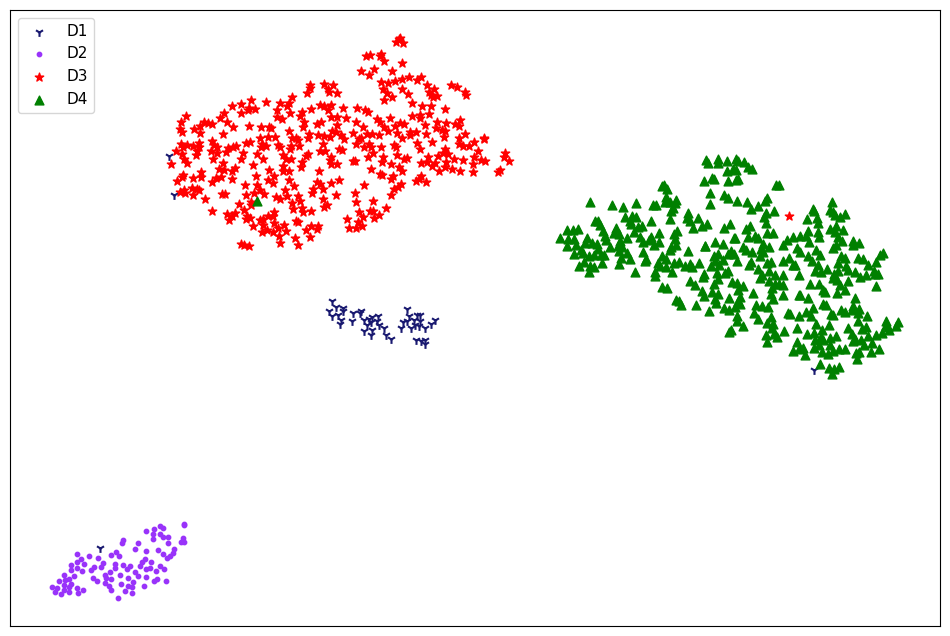

In [5]:
# T-SNE calculation of datasets for domain generalization
image_domain = image_drishti_gs_train + image_rim_one_r3_train + image_refuge_train + image_refuge_val
feature_domain = get_feature(model, device, image_domain)
tsne_domain = tsne.fit_transform(feature_domain)

# visulization of datasets for domain generalization
domain_range1 = num_drishti_gs_train
domain_range2 = domain_range1 + num_rim_one_r3_train
domain_range3 = domain_range2 + num_refuge_train
domain_range4 = domain_range3 + num_refuge_val
plt.figure(figsize=(12, 8))
plt.scatter(tsne_domain[0:domain_range1, 0], tsne_domain[0:domain_range1, 1], 
            marker='1', color='#191970', s=40)
plt.scatter(tsne_domain[domain_range1:domain_range2, 0], tsne_domain[domain_range1:domain_range2, 1], 
            marker='.', color='#9933FA', s=40)
plt.scatter(tsne_domain[domain_range2:domain_range3, 0], tsne_domain[domain_range2:domain_range3, 1], 
            marker='*', color='r', s=40)
plt.scatter(tsne_domain[domain_range3:domain_range4, 0], tsne_domain[domain_range3:domain_range4, 1], 
            marker='^', color='g', s=40)
plt.xticks([])
plt.yticks([])
plt.legend(('D1','D2','D3','D4'), loc='upper left', fontsize=11)
plt.savefig(domain_data_save, dpi=1200, bbox_inches='tight')
plt.show()